<img src="../docs/banniere_projets_GM.png" width="70%" /><br>

-----
<img src="../docs/TheNorthFace_logo.png" width="30%" /><br>

# The North Face e-commerce

>Ce projet est obligatoire pour le bloc 3 (Analyse prédictive de données structurées par l'intelligence artificielle) de la certification CDSD.\
>Concepteur développeur en science des données | RNCP35288

---

## 🎯 Objectif

The North Face souhaite augmenter ses ventes en ligne en s'appuyant sur le *machine learning*. Deux leviers sont visés :

- un **système de recommandation** ("vous aimerez aussi…") sur chaque fiche produit ;
- une **restructuration du catalogue** par extraction automatique de thèmes, pour proposer une navigation plus pertinente que les catégories actuelles.

On travaille sur un corpus de **500 descriptions** de produits issues du catalogue.

**Démarche suivie :**

1. Chargement et nettoyage du texte (les descriptions contiennent du HTML)
2. Prétraitement NLP avec spaCy (minuscules, suppression des *stop words*, lemmatisation)
3. Vectorisation TF-IDF
4. **Partie 1** — Clustering des produits avec DBSCAN
5. **Partie 2** — Système de recommandation de produits basé sur les clusters
6. **Partie 3** — Extraction de thèmes latents avec une LSA (TruncatedSVD)

## 📊 Source des données
On dispose d'un corpus de descriptions d'articles issues du catalogue de produits The North Face.<br>
Les données sont disponibles ici : https://www.kaggle.com/datasets/cclark/product-item-data

---
## 1 - Import des librairies et chargement des données

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spacy
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# On charge le pipeline spaCy une fois pour toutes.
# On désactive le parser et le NER : on n'a besoin que de la lemmatisation,
# ça accélère nettement le traitement.
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

pd.set_option("display.max_colwidth", 120)

NB : Le modèle anglais de spaCy (`en_core_web_sm`) sert à la lemmatisation.

Le fichier `sample-data.csv` contient deux colonnes :
- `id` = identifiant du produit
- `description` = texte commercial

Ces descriptions sont récupérées du site web et contiennent donc des **balises HTML** (`<br>`, `<ul>`, `<b>`…) qu'il faut retirer avant tout traitement.

In [3]:
df = pd.read_csv("../data/raw/sample-data.csv")

print("Dimensions :", df.shape)
print("Valeurs manquantes :", df["description"].isna().sum())
df.head(10)

Dimensions : (500, 2)
Valeurs manquantes : 0


,id,description
0,1,"Active classic boxers - There's a reason why our boxers are a cult favorite - they keep their cool, especially in st..."
1,2,Active sport boxer briefs - Skinning up Glory requires enough movement without your boxers deciding to poach their o...
2,3,Active sport briefs - These superbreathable no-fly briefs are the minimalist's choice for high-octane endeavors. Mad...
3,4,"Alpine guide pants - Skin in, climb ice, switch to rock, traverse a knife-edge ridge and boogie back down - these du..."
4,5,"Alpine wind jkt - On high ridges, steep ice and anything alpine, this jacket serves as a true ""best of all worlds"" s..."
5,6,Ascensionist jkt - Our most technical soft shell for full-on mountain pursuits strikes the alpinist's balance betwee...
6,7,"Atom - A multitasker's cloud nine, the Atom plays the part of courier bag, daypack and carry-on. Its teardrop shape ..."
7,8,"Print banded betina btm - Our fullest coverage bottoms, the Betina fits highest across the hips with a slightly scoo..."
8,9,Baby micro d-luxe cardigan - Micro D-Luxe is a heavenly soft fabric with down-to-earth applications. This cardigan i...
9,10,"Baby sun bucket hat - This hat goes on when the sun rises above the horizon, and stays on when raindrops start falli..."


On regarde une description brute pour visualiser le HTML à nettoyer :

In [4]:
print(df["description"].iloc[0][:400])

Active classic boxers - There's a reason why our boxers are a cult favorite - they keep their cool, especially in sticky situations. The quick-drying, lightweight underwear takes up minimal space in a travel pack. An exposed, brushed waistband offers next-to-skin softness, five-panel construction with a traditional boxer back for a classic fit, and a functional fly. Made of 3.7-oz 100% recycled po


On écrit une petite fonction de nettoyage permettant d'enlever dans l'ordre :
- les balises HTML,
- les entités HTML (`&amp;`, `&nbsp;`…),
- tout ce qui n'est pas une lettre (chiffres, ponctuation, unités…),
- les espaces multiples.

In [5]:
def clean_html(text):
    """Retire le HTML et ne garde que les mots en minuscules."""
    text = re.sub(r"<[^>]+>", " ", text)      # balises <br>, <ul>, <b>...
    text = re.sub(r"&[a-z]+;", " ", text)     # entités HTML
    text = re.sub(r"[^a-zA-Z\s]", " ", text)  # chiffres, ponctuation, unités
    text = re.sub(r"\s+", " ", text)          # espaces multiples
    return text

df["clean"] = df["description"].apply(clean_html)

print('Exemple après nettoyage :')
print("-"*25)
print(df["clean"].iloc[0][:300])

Exemple après nettoyage :
-------------------------
Active classic boxers There s a reason why our boxers are a cult favorite they keep their cool especially in sticky situations The quick drying lightweight underwear takes up minimal space in a travel pack An exposed brushed waistband offers next to skin softness five panel construction with a tradi


---
## 2 - Prétraitement NLP avec spaCy

Le texte est encore "brut". On le passe dans spaCy pour :

- mettre tout le texte en **minuscules**

- **lemmatiser** chaque mot, c'est-à-dire le ramener à sa forme de base (*running* → *run*, *jackets* → *jacket*). Ça évite de compter séparément des variantes du même mot.

- **supprimer les *stop words*** (mots vides très fréquents : *the*, *and*, *with*…) qui n'apportent pas de sens.

- écarter les mots trop courts (≤ 2 lettres), c'est souvent du bruit.

In [6]:
def preprocess(text):
    # Lemmatise le texte et retire stop words / ponctuation / mots courts.
    doc = nlp(text)
    lemmas = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and len(token.lemma_) > 2
    ]
    return " ".join(lemmas)


# nlp.pipe traite les textes par lots : beaucoup plus rapide qu'une boucle .apply()
df["processed"] = [preprocess(t) for t in df["clean"]]

print("Avant :", df["clean"].iloc[0][:150])
print()
print("Après :", df["processed"].iloc[0][:150])

Avant : Active classic boxers There s a reason why our boxers are a cult favorite they keep their cool especially in sticky situations The quick drying lightw

Après : active classic boxer reason boxer cult favorite cool especially sticky situation quick dry lightweight underwear take minimal space travel pack expose


---
## 3 - Vectorisation TF-IDF

Les algorithmes ne travaillent pas sur du texte mais sur des nombres. On transforme donc chaque description en vecteur avec **TF-IDF** (*Term Frequency – Inverse Document Frequency*) :

- un mot pèse d'autant plus qu'il est **fréquent dans une description**,
- mais son poids est réduit s'il apparaît dans **beaucoup de descriptions** (donc peu discriminant).

Quelques réglages utiles :
- `max_features=600` : on garde les 600 termes les plus pertinents pour limiter le bruit.
- `min_df=2` : on ignore les mots qui n'apparaissent que dans un seul produit.

In [7]:
vectorizer = TfidfVectorizer(max_features=600, min_df=2)
tfidf = vectorizer.fit_transform(df["processed"])

print("Matrice TF-IDF :", tfidf.shape)
print("(lignes = produits, colonnes = mots du vocabulaire)")

Matrice TF-IDF : (500, 600)
(lignes = produits, colonnes = mots du vocabulaire)


## Partie 1 — Clustering des produits (DBSCAN)

**Objectif :** regrouper les produits dont les descriptions se ressemblent.

On utilise **DBSCAN**, un algorithme qui forme des groupes par densité. Son intérêt ici :
- il **n'impose pas** de fixer le nombre de clusters à l'avance ;
- il sait isoler les produits atypiques en **outliers** (étiquette `-1`).

Pour du texte, on utilise la distance **cosine** (et non euclidienne) : elle compare l'orientation des vecteurs, ce qui correspond mieux à la similarité de contenu.

Deux paramètres à régler :
- `eps` : rayon de voisinage. Plus il est grand, plus les clusters sont gros.
- `min_samples` : nombre minimum de produits pour former un cluster.

Les valeurs ci-dessous ont été choisies pour obtenir une dizaine de clusters avec peu d'outliers.

In [8]:
dbscan = DBSCAN(eps=0.6, min_samples=2, metric="cosine")
df["cluster"] = dbscan.fit_predict(tfidf)

n_clusters = df["cluster"].nunique() - (1 if -1 in df["cluster"].values else 0)
n_outliers = (df["cluster"] == -1).sum()

print(f"Nombre de clusters : {n_clusters}")
print(f"Outliers          : {n_outliers} ({n_outliers / len(df) * 100:.1f} %)")
print()
print("Taille de chaque cluster :")
print(df["cluster"].value_counts().sort_index())

Nombre de clusters : 13
Outliers          : 7 (1.4 %)

Taille de chaque cluster :
cluster
-1       7
 0     420
 1      10
 2       8
 3       2
 4      24
 5       4
 6       2
 7       5
 8       2
 9       7
 10      3
 11      4
 12      2
Name: count, dtype: int64


### <u>Qualité du clustering</u>

On mesure la séparation des clusters avec le **silhouette score** (entre -1 et 1 ; plus c'est proche de 1, mieux les groupes sont distincts).<br>
On l'évalue uniquement sur les produits réellement assignés à un cluster, en excluant les outliers.

In [9]:
mask = df["cluster"] != -1
labels = df.loc[mask, "cluster"]

if labels.nunique() > 1:
    score = silhouette_score(tfidf[mask.values], labels, metric="cosine")
    print(f"Silhouette score (cosine) : {score:.3f}")
else:
    print("Pas assez de clusters pour calculer le score.")

Silhouette score (cosine) : 0.017


### <u>Visualisation : un wordcloud par cluster</u>

Un **wordcloud** affiche les mots d'un groupe avec une taille proportionnelle à leur fréquence. C'est un bon moyen de **donner un sens** à chaque cluster (vêtements imperméables, sous-vêtements techniques, sacs…).

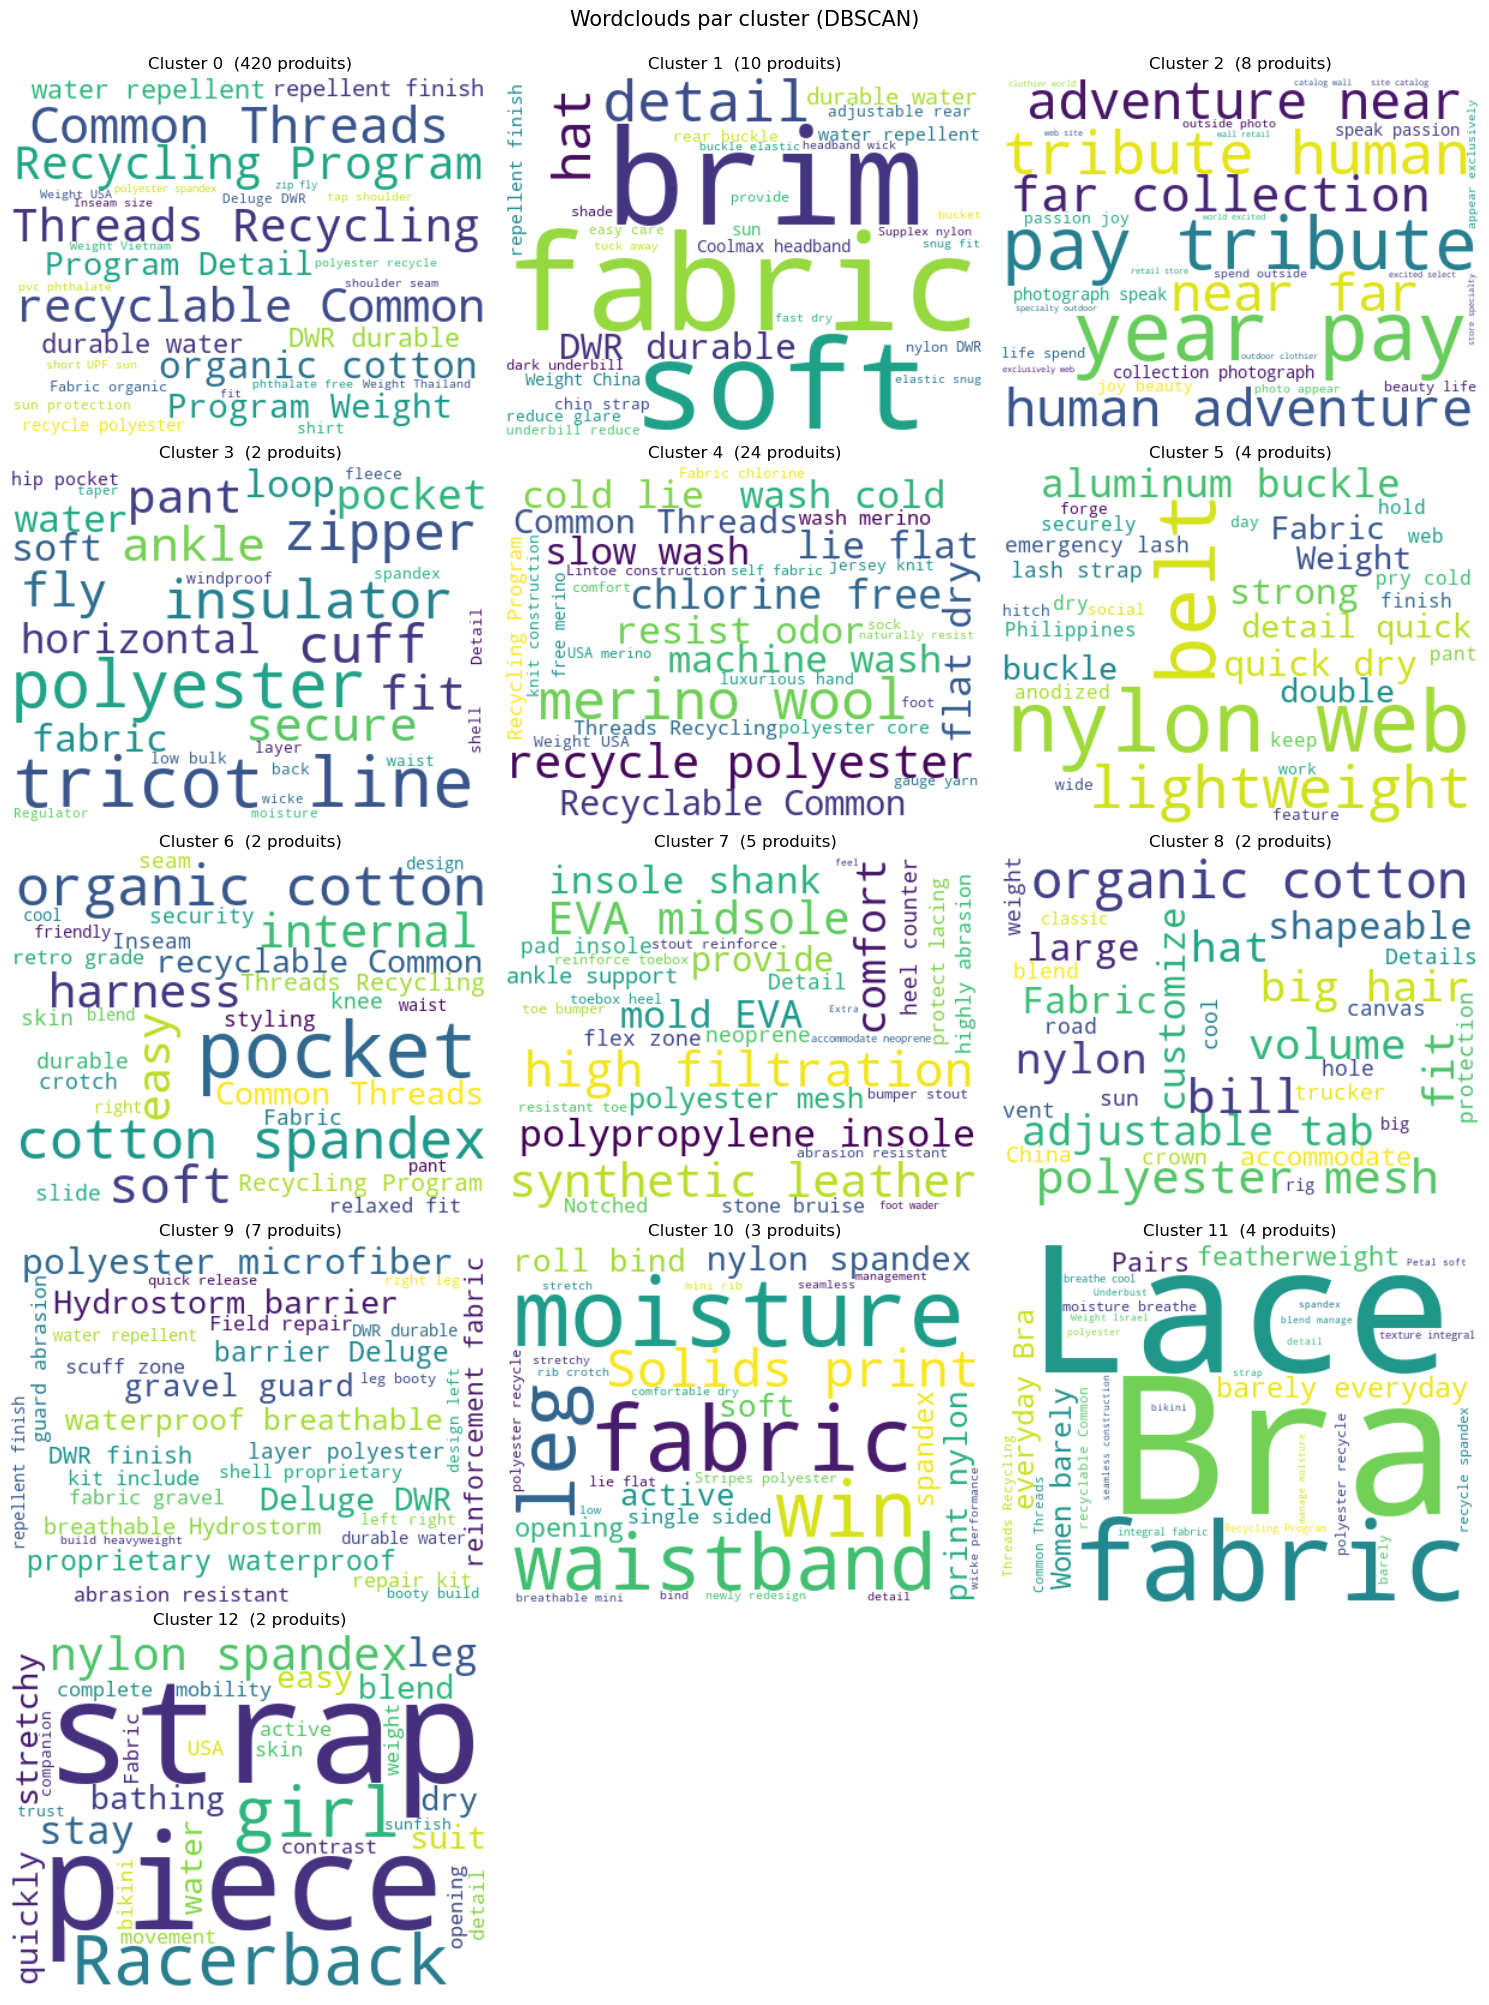

In [10]:
cluster_ids = sorted(c for c in df["cluster"].unique() if c != -1)

n_cols = 3
n_rows = -(-len(cluster_ids) // n_cols)  # arrondi supérieur

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, cid in zip(axes, cluster_ids):
    text = " ".join(df.loc[df["cluster"] == cid, "processed"])
    wc = WordCloud(width=400, height=300, background_color="white",
                   max_words=30, colormap="viridis").generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Cluster {cid}  ({(df['cluster'] == cid).sum()} produits)")
    ax.axis("off")

# on masque les sous-graphiques inutilisés
for ax in axes[len(cluster_ids):]:
    ax.axis("off")

plt.suptitle("Wordclouds par cluster (DBSCAN)", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()

## Partie 2 — Système de recommandation

L'idée est directe : **deux produits d'un même cluster sont considérés comme similaires**. Pour un produit donné, on propose donc d'autres produits du même cluster.

La fonction `find_similar_items` prend un `item_id` et renvoie une liste de 5 identifiants de produits similaires.

Cas particulier : si le produit est un **outlier** (cluster `-1`), il n'a pas de groupe. On bascule alors sur la **similarité cosine** calculée directement sur la matrice TF-IDF pour trouver ses voisins les plus proches.

In [11]:
def find_similar_items(item_id, n=5):
    """Renvoie n produits similaires à `item_id`.

    - Cas normal : on prend d'autres produits du même cluster.
    - Cas outlier (cluster -1) : on cherche les voisins par similarité cosine.
    """
    if item_id not in df["id"].values:
        return f"Produit {item_id} introuvable."

    cluster = df.loc[df["id"] == item_id, "cluster"].iloc[0]

    # Produit isolé : on calcule la similarité avec tous les autres
    if cluster == -1:
        idx = df.index[df["id"] == item_id][0]
        sims = cosine_similarity(tfidf[idx], tfidf).flatten()
        sims[idx] = 0  # on exclut le produit lui-même
        best = sims.argsort()[::-1][:n]
        return df.iloc[best]["id"].tolist()

    # Cas standard : autres produits du même cluster
    same_cluster = df[(df["cluster"] == cluster) & (df["id"] != item_id)]
    return same_cluster["id"].head(n).tolist()


# Petit test sur quelques produits
for test_id in [1, 25, 100]:
    print(f"Produit {test_id} -> similaires : {find_similar_items(test_id)}")

Produit 1 -> similaires : [2, 3, 4, 5, 6]
Produit 25 -> similaires : [1, 2, 3, 4, 5]
Produit 100 -> similaires : [1, 2, 3, 4, 5]


### <u>Interface utilisateur</u>

On utilise `input()` pour permettre à un utilisateur de saisir l'identifiant d'un produit et d'obtenir directement ses recommandations, avec un extrait de chaque description.

In [12]:
try:
    item_id = int(input("Entrez l'id d'un produit (1 à 500) : "))
    reco = find_similar_items(item_id)

    print(f"\nProduits recommandés pour le produit {item_id} : {reco}\n")
    for rid in reco:
        desc = df.loc[df["id"] == rid, "clean"].iloc[0]
        print(f"  [{rid}] {desc[:110]}...")
except ValueError:
    print("Merci d'entrer un nombre entier valide.")


Produits recommandés pour le produit 12 : [1, 2, 3, 4, 5]

  [1] Active classic boxers There s a reason why our boxers are a cult favorite they keep their cool especially in s...
  [2] Active sport boxer briefs Skinning up Glory requires enough movement without your boxers deciding to poach the...
  [3] Active sport briefs These superbreathable no fly briefs are the minimalist s choice for high octane endeavors ...
  [4] Alpine guide pants Skin in climb ice switch to rock traverse a knife edge ridge and boogie back down these dur...
  [5] Alpine wind jkt On high ridges steep ice and anything alpine this jacket serves as a true best of all worlds s...


## Partie 3 — Extraction de thèmes (LSA / TruncatedSVD)

*Cette partie est indépendante des deux précédentes.*

On cherche maintenant les **thèmes latents** présents dans le catalogue, à l'aide d'une **LSA** (*Latent Semantic Analysis*) reposant sur `TruncatedSVD`.

Différence importante avec le clustering : ici un produit n'appartient pas à un seul groupe, il est associé à **un mélange de plusieurs thèmes**. Pour simplifier l'interprétation, on retient pour chaque produit son **thème dominant**.

On choisit `n_components=15` (soit 15 thèmes), dans la fourchette 10-20 demandée.

In [13]:
N_TOPICS = 15

svd = TruncatedSVD(n_components=N_TOPICS, random_state=42)
topic_matrix = svd.fit_transform(tfidf)

# Matrice produits x thèmes demandée dans l'énoncé
topic_encoded_df = pd.DataFrame(
    topic_matrix,
    columns=[f"topic_{i}" for i in range(N_TOPICS)],
    index=df["id"],
)

# Thème dominant de chaque produit = composante la plus forte
df["main_topic"] = topic_matrix.argmax(axis=1)

print("Matrice des thèmes :", topic_encoded_df.shape)
print(f"Variance expliquée cumulée : {svd.explained_variance_ratio_.sum():.1%}")
print()
print("Répartition des produits par thème dominant :")
print(df["main_topic"].value_counts().sort_index())

Matrice des thèmes : (500, 15)
Variance expliquée cumulée : 36.7%

Répartition des produits par thème dominant :
main_topic
0     288
1      47
2      41
4      12
5       3
6      29
7      28
8      15
9       8
10     10
11      2
13      8
14      9
Name: count, dtype: int64


### <u>Visualisation : un wordcloud par thème</u>

Pour chaque thème, on regarde les mots qui lui contribuent le plus. Dans la décomposition SVD, ce sont les **poids les plus élevés** de la composante. On ne garde que les poids positifs (les mots qui "tirent" le thème dans sa direction).

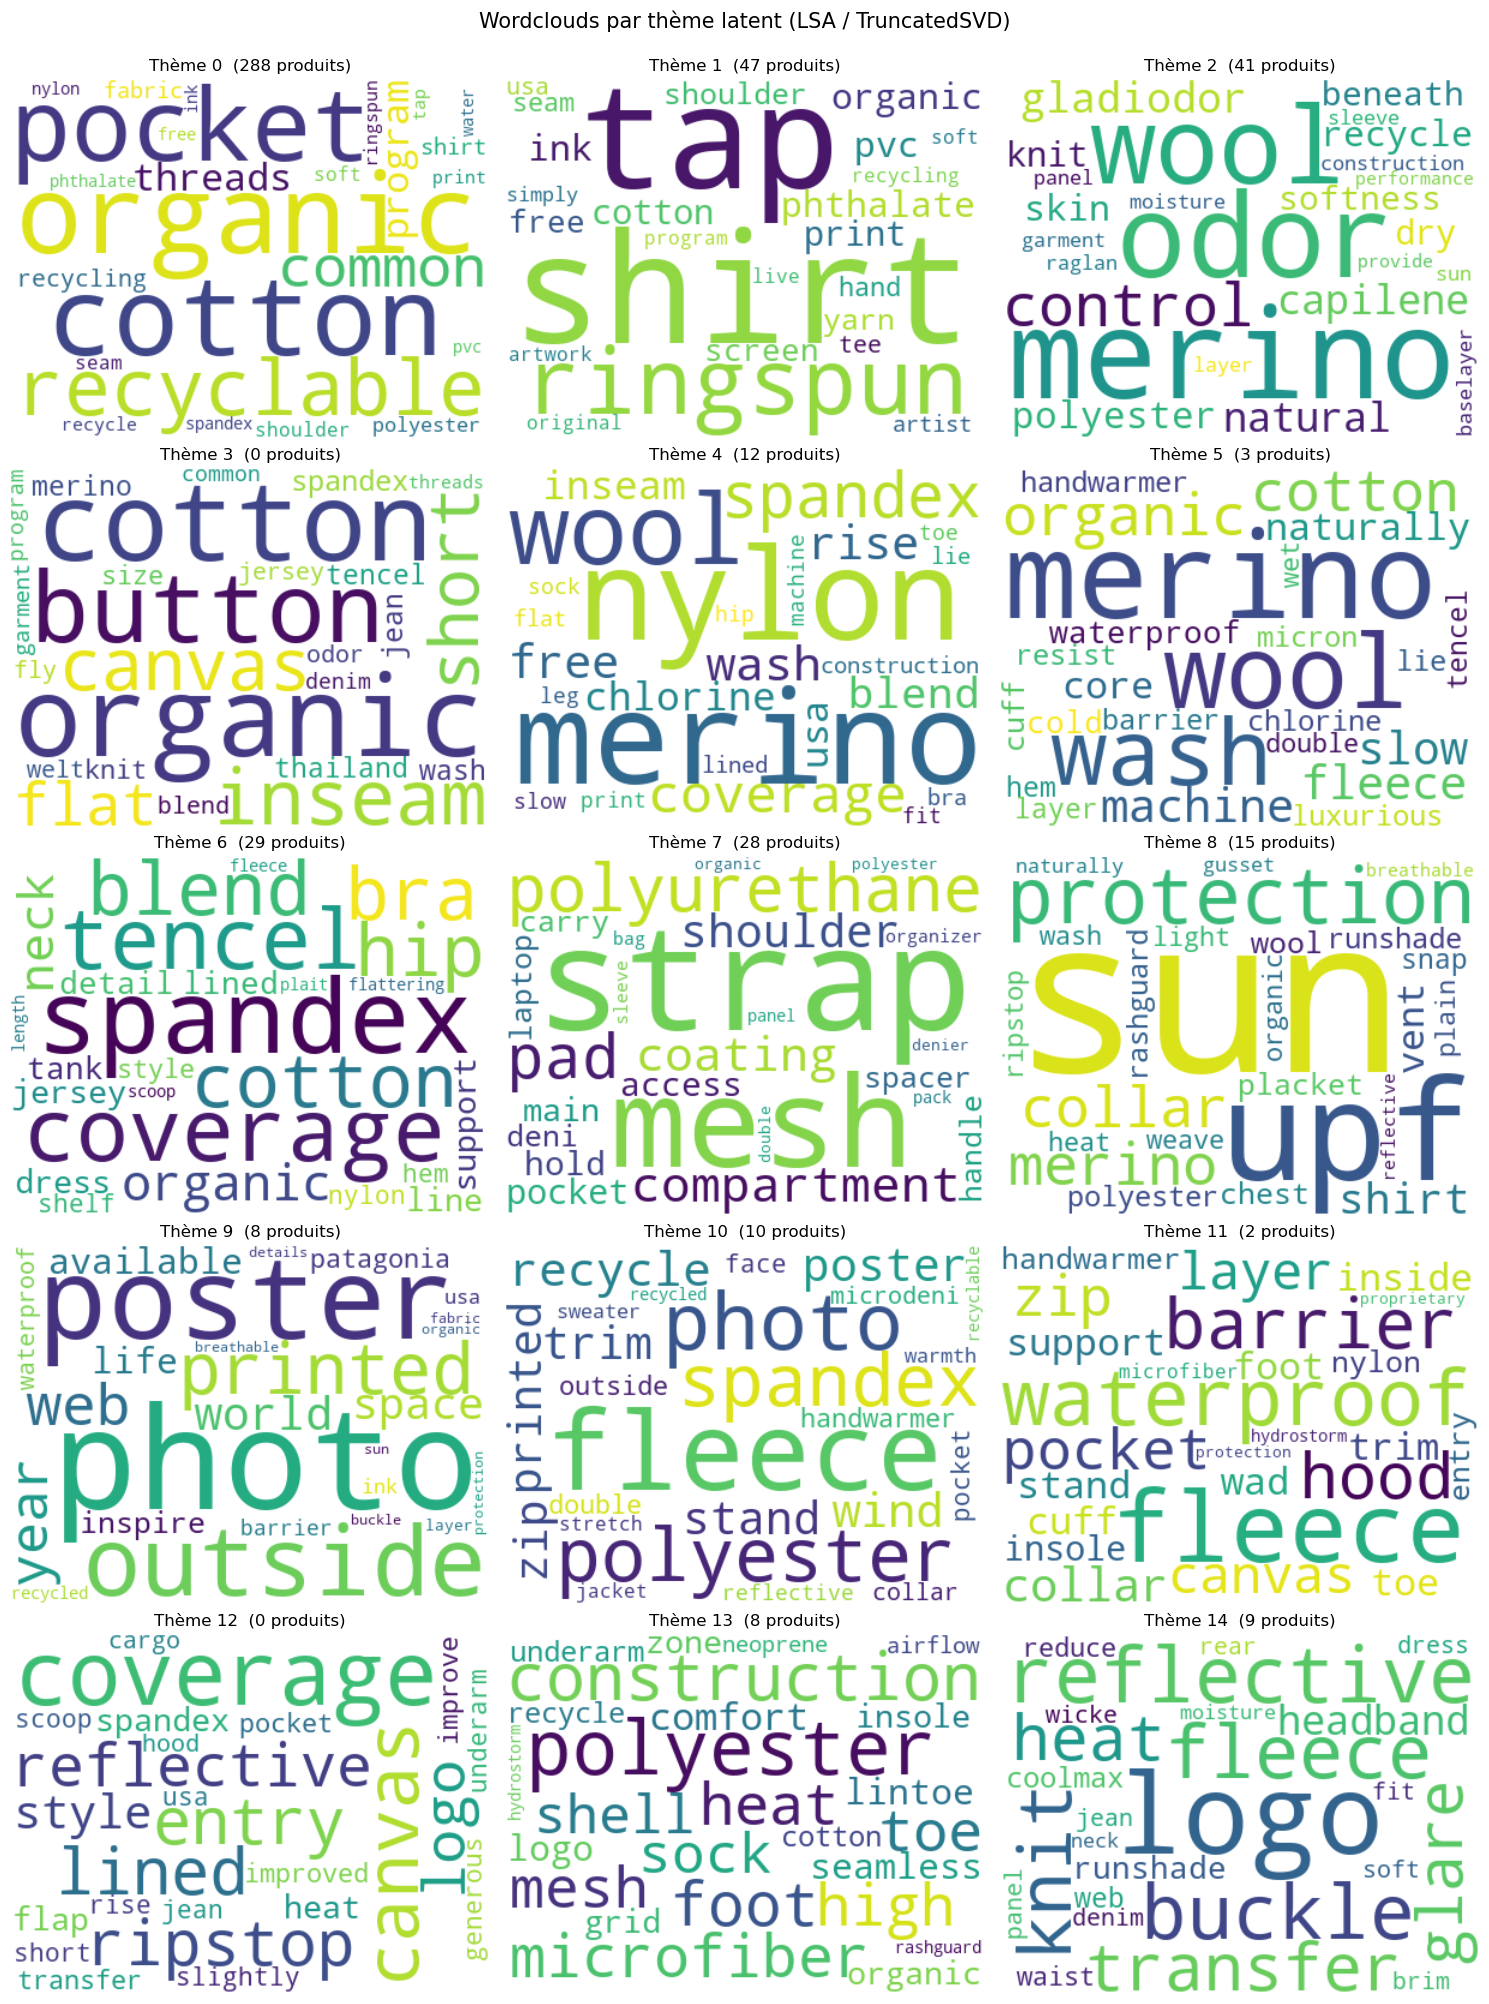

In [14]:
features = vectorizer.get_feature_names_out()

n_cols = 3
n_rows = -(-N_TOPICS // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i in range(N_TOPICS):
    # poids des mots pour le thème i (on ne garde que les positifs)
    weights = {features[j]: w for j, w in enumerate(svd.components_[i]) if w > 0}

    if weights:
        wc = WordCloud(width=400, height=300, background_color="white",
                       max_words=25, colormap="viridis").generate_from_frequencies(weights)
        axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"Thème {i}  ({(df['main_topic'] == i).sum()} produits)")
    axes[i].axis("off")

for ax in axes[N_TOPICS:]:
    ax.axis("off")

plt.suptitle("Wordclouds par thème latent (LSA / TruncatedSVD)", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()

---
## 4 - Conclusion générale

**<u>Partie 1 — Clustering DBSCAN**</u><br>
DBSCAN avec la distance cosine regroupe les produits aux descriptions proches sans qu'on ait à fixer le nombre de groupes. On obtient une dizaine de clusters cohérents, avec très peu d'outliers, que les wordclouds permettent d'interpréter (sous-vêtements techniques, vestes, sacs, etc.).

**<u>Partie 2 — Recommandation de produits**</u><br>
La fonction `find_similar_items` exploite ces clusters pour proposer 5 produits similaires — directement utilisable dans une section "vous aimerez aussi" sur les fiches produits. Le repli sur la similarité cosine gère proprement les produits isolés.

**<u>Partie 3 — Topic modeling LSA**</u><br>
TruncatedSVD fait ressortir des thèmes latents transverses au catalogue. Contrairement au clustering, un produit peut relever de plusieurs thèmes : l'approche est donc complémentaire et pourrait servir à enrichir le système de catégories du site.<br><br>

### <u>Pistes d'amélioration :</u><br>
- Tester d'autres valeurs de paramètres `eps` et `min_samples`
- Comparer DBSCAN à un KMeans
- Remplacer TF-IDF par des *embeddings* (Word2Vec, sentence-transformers) pour capturer le sens au-delà des mots exacts